In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from skimage.feature import hog, local_binary_pattern
import seaborn as sns
import pandas as pd

# Step 1: Load and visualize MNIST dataset

In [11]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x = np.concatenate((x_train, x_test))
y = np.concatenate((y_train, y_test))


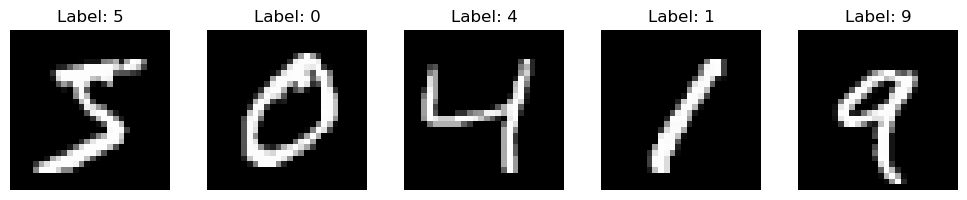

In [12]:
# Show 5 sample images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
# Step 2: Normalize and One-hot encode labels
x = x / 255.0  # Normalize
y_cat = to_categorical(y)  # One-hot encode


In [14]:
# Step 3a: Raw Pixels (flattened)
x_raw = x.reshape((x.shape[0], -1))

In [15]:
# Step 3b: HOG features
def extract_hog_features(images):
    hog_features = []
    for img in images:
        feat = hog(img, pixels_per_cell=(4, 4), cells_per_block=(2, 2), feature_vector=True)
        hog_features.append(feat)
    return np.array(hog_features)

x_hog = extract_hog_features(x)

In [16]:
# Step 3c: LBP features
def extract_lbp_features(images):
    lbp_features = []
    for img in images:
        lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)
        lbp_features.append(lbp_hist)
    return np.array(lbp_features)

x_lbp = extract_lbp_features(x)

c:\Anaconda\Lib\site-packages\skimage\feature\texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


In [17]:
# Function to build and train a simple ANN
def train_ann(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = Sequential([
        Input(shape=(X.shape[1],)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    # Compile and train the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_test, y_test), verbose=0)
    
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)




    # Plotting the results
    plt.figure(figsize=(10, 5))
    plt.title(f"{name} Model Accuracy")
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='test')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show() 
    print(f"\n{name} Accuracy: {np.mean(y_pred == y_true) * 100:.2f}%")
    

    # Classification report and confusion matrix
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_true, y_pred))

    # Confusion matrix
    print("Confusion Matrix:")
    plt.figure(figsize=(10, 5))
    plt.title(f"{name} Confusion Matrix")
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='coolwarm')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show() 
    return history, y_true, y_pred

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


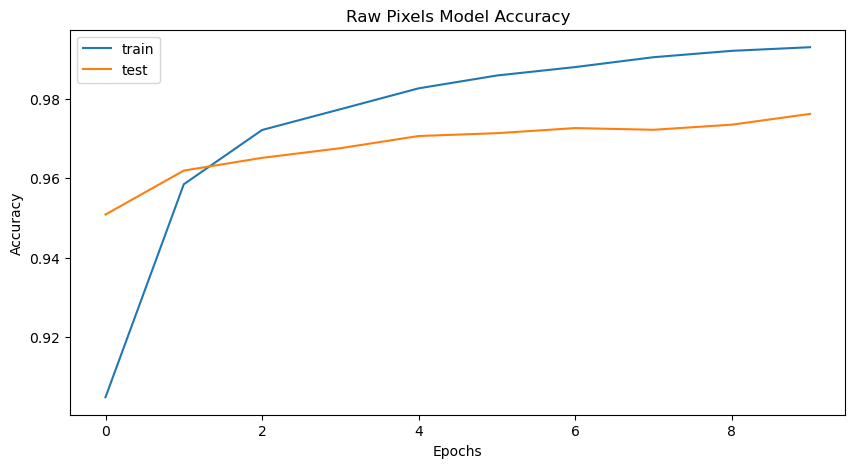


Raw Pixels Accuracy: 97.62%

Raw Pixels Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.97      0.98      0.97      1380
           3       0.97      0.98      0.97      1433
           4       0.96      0.99      0.97      1295
           5       0.97      0.97      0.97      1273
           6       0.98      0.99      0.98      1396
           7       0.98      0.97      0.98      1503
           8       0.97      0.96      0.96      1357
           9       0.97      0.96      0.97      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000

Confusion Matrix:


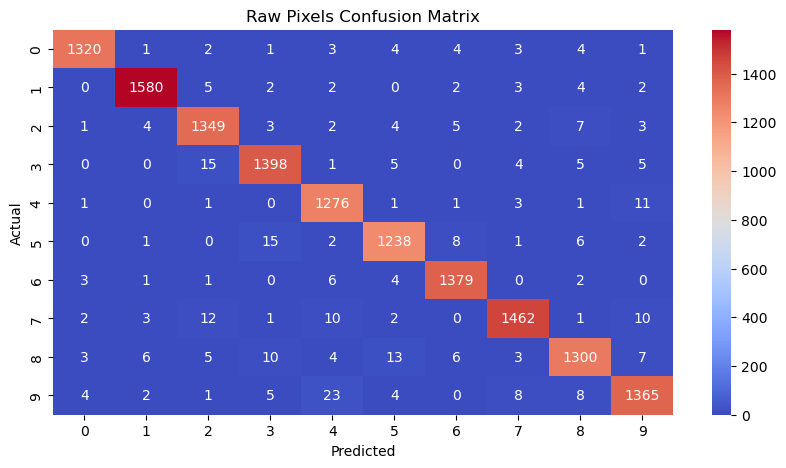

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


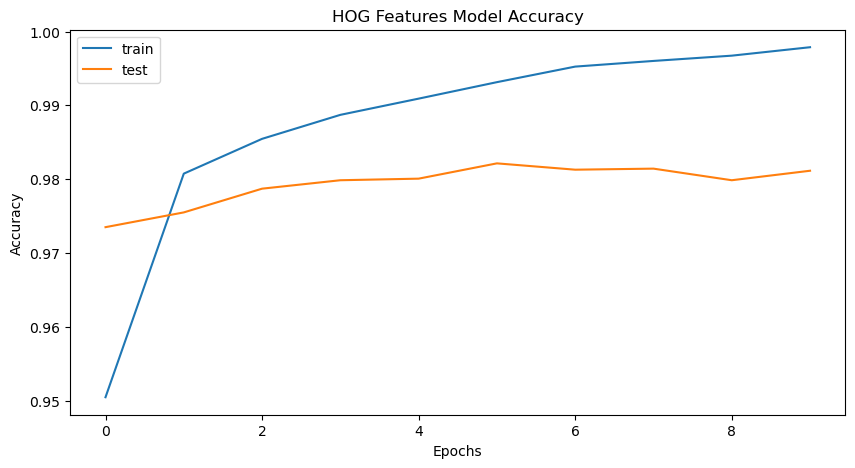


HOG Features Accuracy: 98.11%

HOG Features Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.98      1.00      0.99      1600
           2       0.97      0.99      0.98      1380
           3       0.98      0.98      0.98      1433
           4       0.99      0.96      0.98      1295
           5       0.99      0.98      0.98      1273
           6       0.99      0.99      0.99      1396
           7       0.97      0.98      0.98      1503
           8       0.98      0.97      0.97      1357
           9       0.97      0.97      0.97      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000

Confusion Matrix:


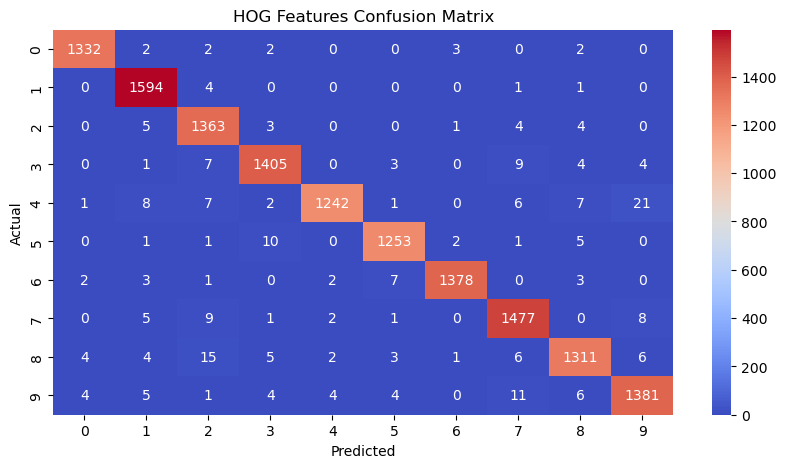

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step


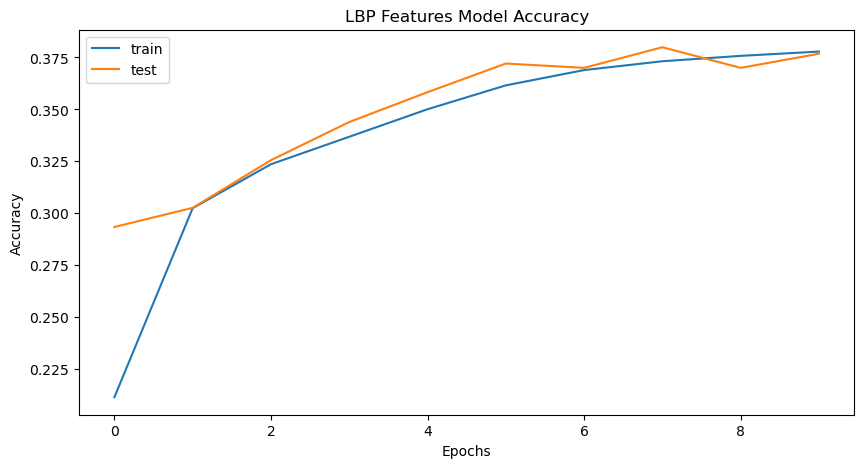


LBP Features Accuracy: 37.68%

LBP Features Classification Report:

              precision    recall  f1-score   support

           0       0.37      0.62      0.47      1343
           1       0.84      0.95      0.89      1600
           2       0.23      0.03      0.05      1380
           3       0.19      0.09      0.13      1433
           4       0.20      0.14      0.17      1295
           5       0.23      0.15      0.18      1273
           6       0.23      0.02      0.04      1396
           7       0.32      0.67      0.44      1503
           8       0.47      0.57      0.51      1357
           9       0.23      0.39      0.29      1420

    accuracy                           0.38     14000
   macro avg       0.33      0.36      0.32     14000
weighted avg       0.34      0.38      0.33     14000

Confusion Matrix:


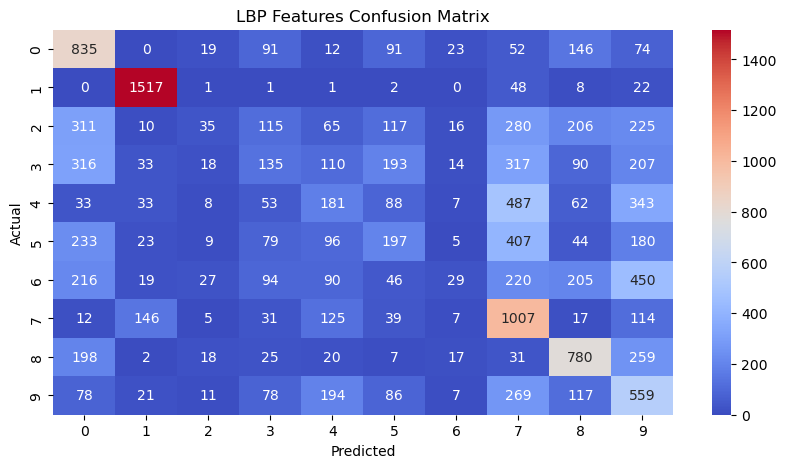

In [18]:
# Step 4 & 5: Train and evaluate on all three features
history_raw, y_true_raw, y_pred_raw = train_ann(x_raw, y_cat, "Raw Pixels")
history_hog, y_true_hog, y_pred_hog = train_ann(x_hog, y_cat, "HOG Features")
history_lbp, y_true_lbp, y_pred_lbp = train_ann(x_lbp, y_cat, "LBP Features")